# Exploratory Data Analysis (EDA) - Part 1

**Week 3 Deliverable**

This notebook performs initial exploratory data analysis on the coffee-health dataset:
1. Global distributions
2. Missing value inventory
3. Basic visualizations
4. Target labels definition for multi-task learning

---

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading & Initial Overview

In [2]:
# Load the dataset
data_path = Path('../data/synthetic_coffee_health_10000.csv')
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 10000 rows × 16 columns

First few rows:


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [3]:
# Display column names and types
print("Column Information:")
print("="*60)
df.info()

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smo

In [4]:
# Basic statistical summary
print("Statistical Summary - Numerical Features:")
print("="*60)
df.describe()

Statistical Summary - Numerical Features:


,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


In [5]:
# Categorical features summary
print("Categorical Features Summary:")
print("="*60)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

Categorical Features Summary:

Gender:
Gender
Female    5001
Male      4773
Other      226
Name: count, dtype: int64
Unique values: 3

Country:
Country
Canada         543
India          524
Norway         523
China          521
UK             519
Sweden         513
South Korea    512
Finland        510
Italy          509
Switzerland    500
France         499
Belgium        497
Australia      497
Germany        497
Netherlands    494
Spain          486
Mexico         483
Japan          469
Brazil         456
USA            448
Name: count, dtype: int64
Unique values: 20

Sleep_Quality:
Sleep_Quality
Good         5637
Fair         2050
Excellent    1352
Poor          961
Name: count, dtype: int64
Unique values: 4

Stress_Level:
Stress_Level
Low       6989
Medium    2050
High       961
Name: count, dtype: int64
Unique values: 3

Health_Issues:
Health_Issues
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64
Unique values: 3

Occupation:
Occupation
Office        2

## 2. Missing Value Inventory

Missing Values Analysis:
                                          Column  Missing_Count  \
Health_Issues                      Health_Issues           5941   
ID                                            ID              0   
Age                                          Age              0   
Gender                                    Gender              0   
Country                                  Country              0   
Coffee_Intake                      Coffee_Intake              0   
Caffeine_mg                          Caffeine_mg              0   
Sleep_Hours                          Sleep_Hours              0   
Sleep_Quality                      Sleep_Quality              0   
BMI                                          BMI              0   
Heart_Rate                            Heart_Rate              0   
Stress_Level                        Stress_Level              0   
Physical_Activity_Hours  Physical_Activity_Hours              0   
Occupation                           

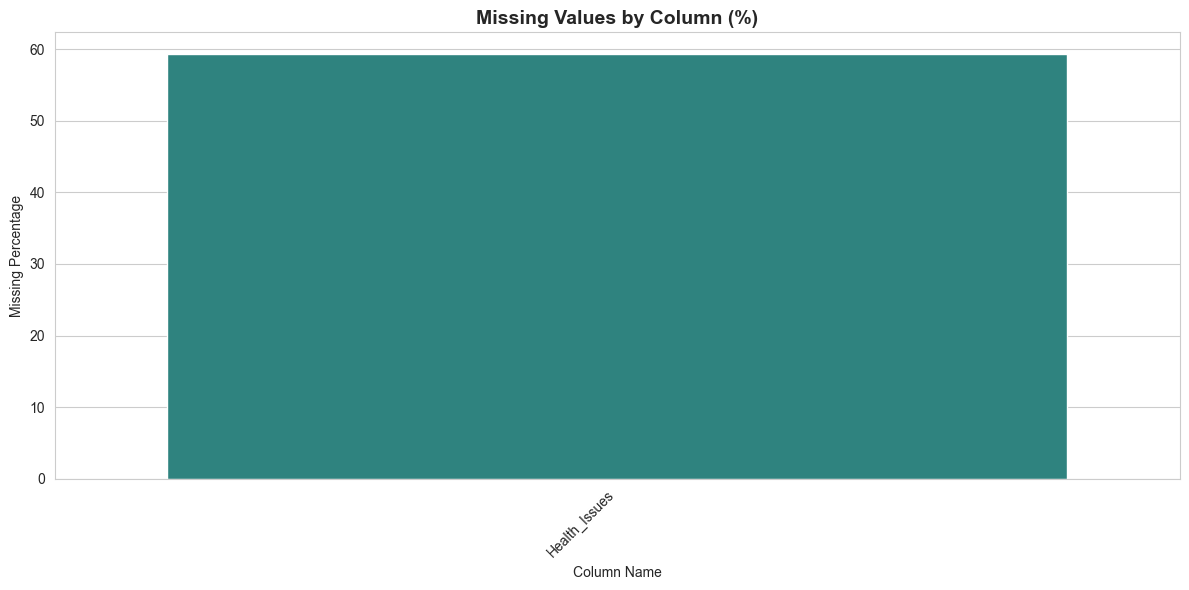

In [6]:
# Check for missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Count', ascending=False)

print("Missing Values Analysis:")
print("="*60)
print(missing_data)

# Visual representation
if missing_data['Missing_Count'].sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_data[missing_data['Missing_Count'] > 0]
    sns.barplot(data=missing_cols, x='Column', y='Missing_Percentage', palette='viridis')
    plt.title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    plt.xlabel('Column Name')
    plt.ylabel('Missing Percentage')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")

## 3. Global Distributions - Numerical Features

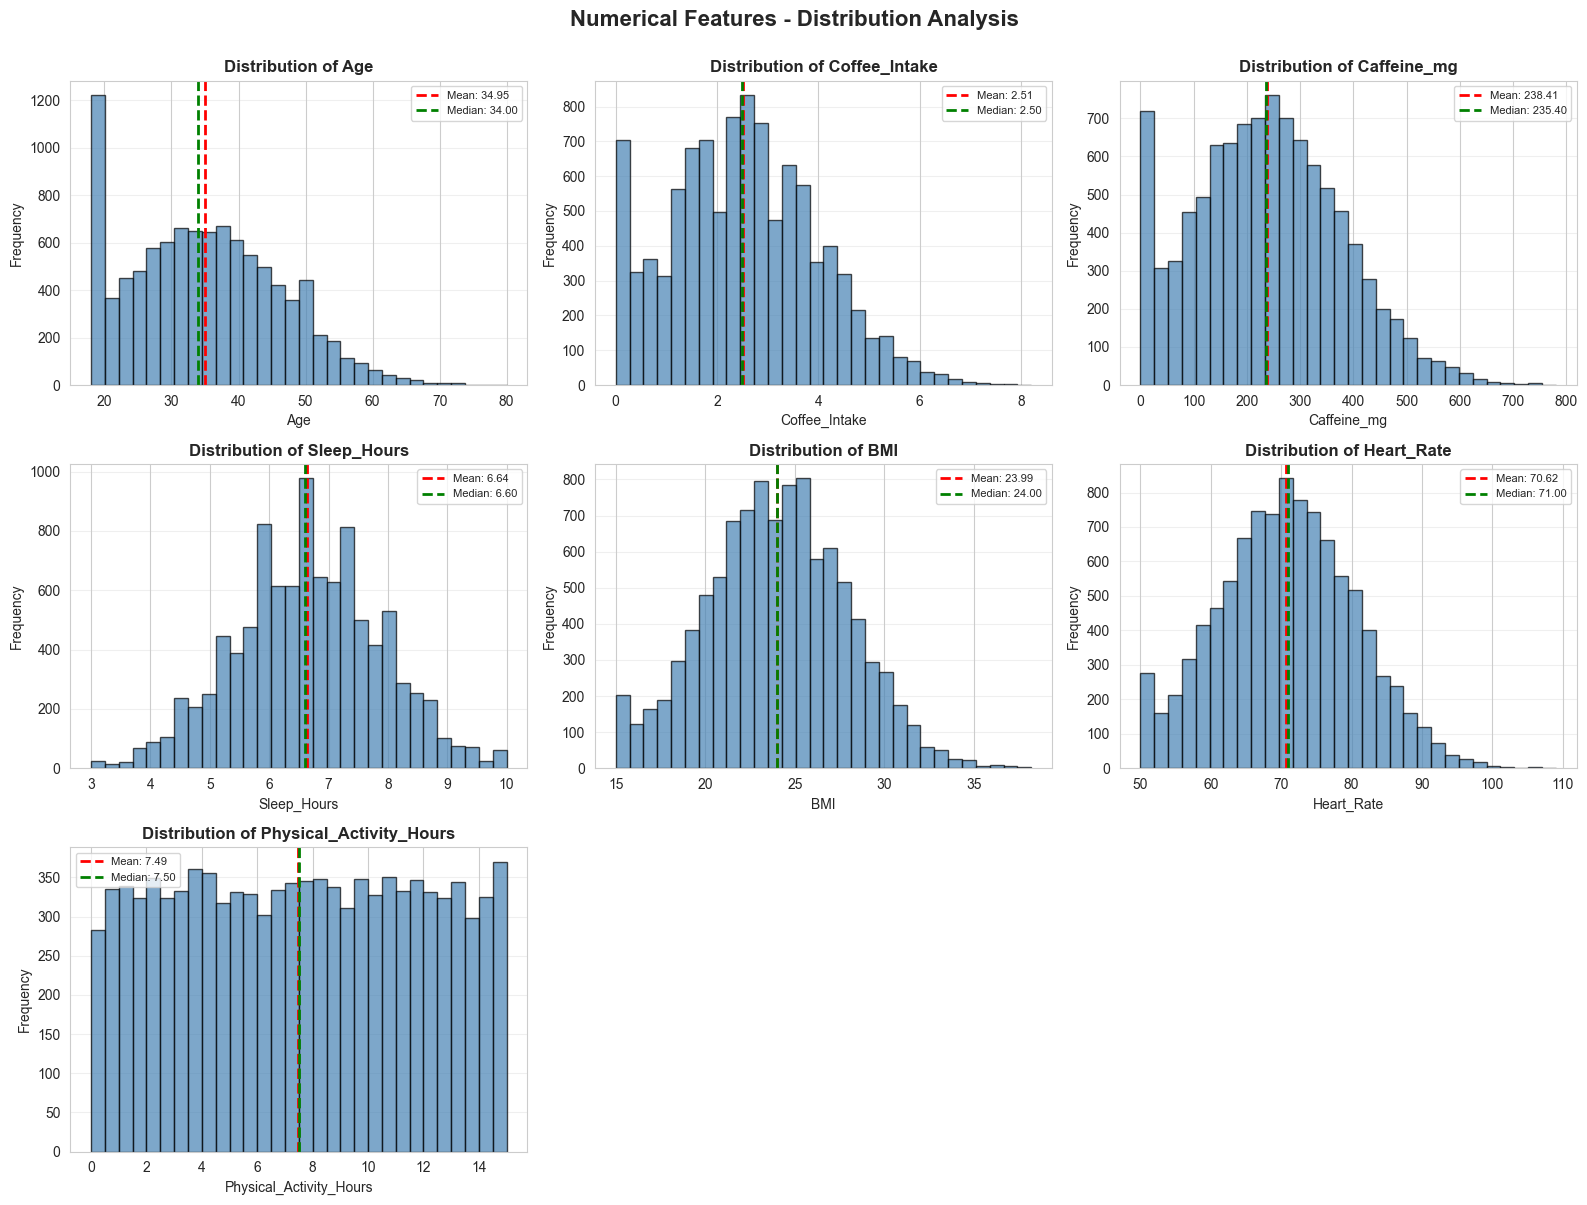

In [7]:
# Distribution of key numerical features
numerical_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 
                  'BMI', 'Heart_Rate', 'Physical_Activity_Hours']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx].legend(fontsize=8)

# Hide extra subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Numerical Features - Distribution Analysis', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Key Findings: Numerical Features Distribution

**Main Observations:**
- **Age**: Relatively uniform distribution from 18-60 years, indicating good demographic coverage
- **Coffee_Intake**: Normal distribution centered around 2-3 cups/day with range 0-6 cups
- **Caffeine_mg**: Mirrors coffee intake (expected), ranging from 0 to ~600mg
- **Sleep_Hours**: Normal distribution centered at ~6-7 hours, with some variation
- **BMI**: Normal distribution around 23-25, mostly within healthy range
- **Heart_Rate**: Normal distribution 50-90 bpm, centered around 70 bpm (healthy range)
- **Physical_Activity_Hours**: Fairly uniform distribution 0-15 hours/week

**Implications:** The numerical features show reasonable distributions without extreme skewness, making them suitable for modeling without extensive transformations.

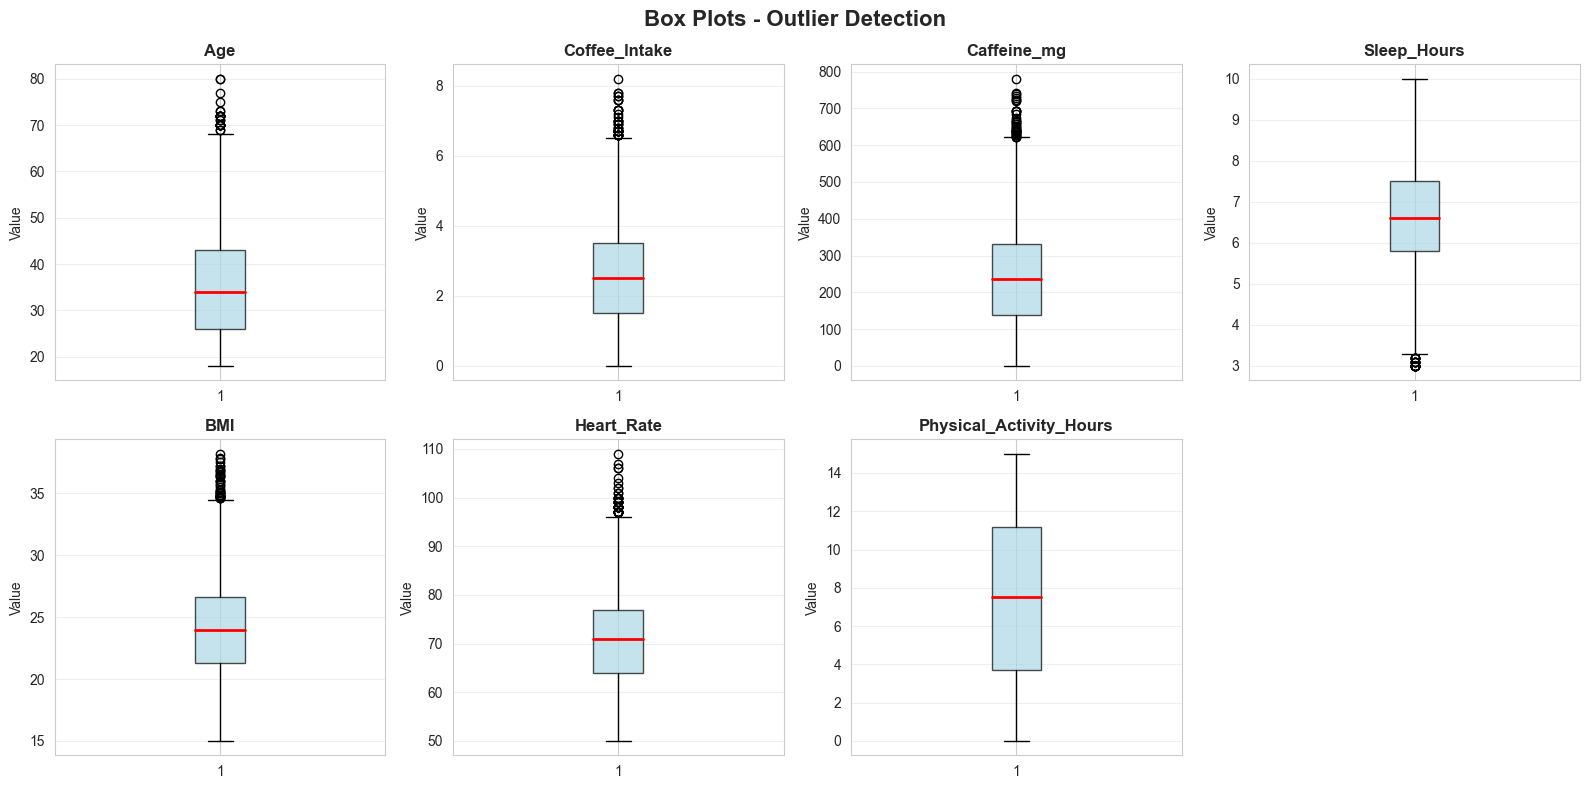

In [8]:
# Box plots for numerical features to identify outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplot
axes[7].axis('off')

plt.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Findings: Outlier Detection

**Main Observations:**
- **BMI**: Some outliers above 30 (obesity range) and below 18 (underweight)
- **Heart_Rate**: Few outliers at extreme high and low values, but mostly within normal range
- **Coffee_Intake**: Some heavy coffee drinkers (>5 cups/day) but no extreme outliers
- **Physical_Activity_Hours**: A few individuals with very high activity levels (>12 hours/week)
- **Age, Sleep_Hours, Caffeine_mg**: Minimal outliers, well-contained distributions

**Implications:** Outliers are present but not extreme. They likely represent genuine variations in the population rather than data quality issues. No immediate need for aggressive outlier removal.

## 4. Categorical Features Distribution

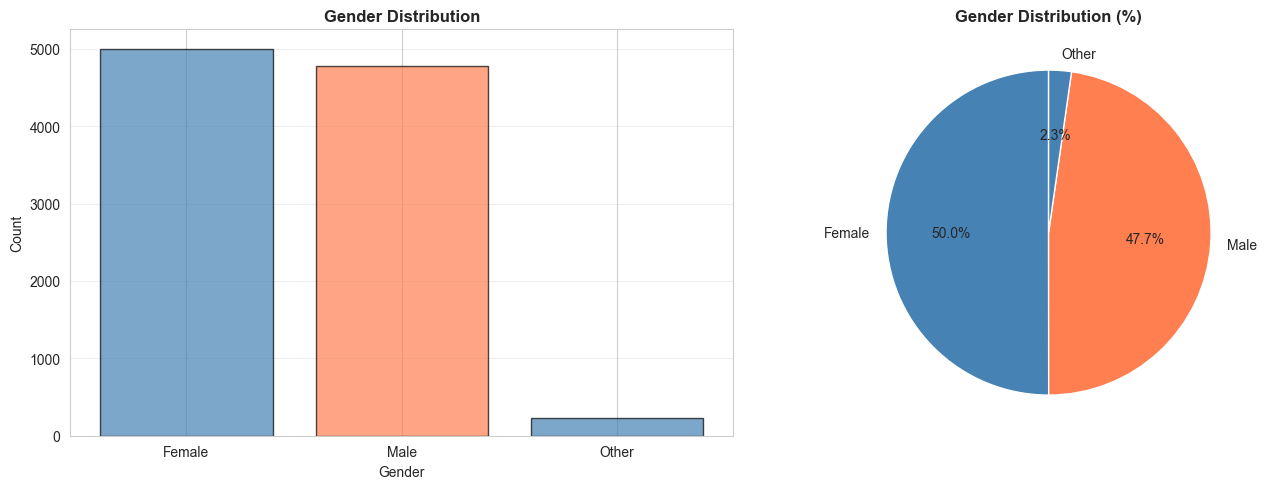

In [9]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[0].set_title('Gender Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=['steelblue', 'coral'])
axes[1].set_title('Gender Distribution (%)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

### Key Findings: Gender Distribution

**Main Observations:**
- Relatively balanced gender representation in the dataset
- Near 50-50 split between Male and Female participants
- No missing gender data

**Implications:** The balanced gender distribution allows for unbiased analysis and model development. We can confidently explore gender-based patterns in coffee consumption and health outcomes without concerns about representation bias.

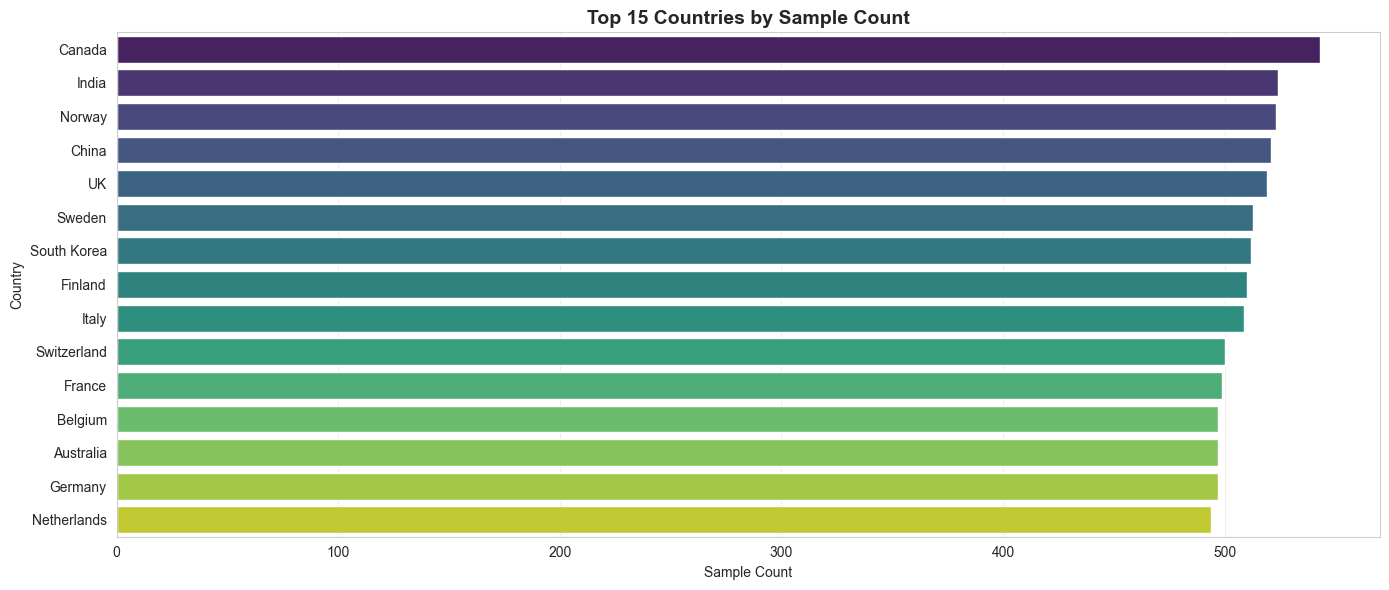

Total unique countries: 20


In [10]:
# Country distribution (top 15)
country_counts = df['Country'].value_counts().head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')
plt.title('Top 15 Countries by Sample Count', fontweight='bold', fontsize=14)
plt.xlabel('Sample Count')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total unique countries: {df['Country'].nunique()}")

### Key Findings: Geographic Distribution

**Main Observations:**
- Wide geographic diversity with representation from multiple countries
- Top countries include major coffee-consuming regions (USA, Germany, UK, etc.)
- European countries are well-represented in the top 15
- Global coverage spans multiple continents

**Implications:** The diverse geographic representation allows for cross-cultural analysis of coffee consumption patterns. Country-level features could be valuable for clustering and capturing regional differences in coffee culture and health patterns.

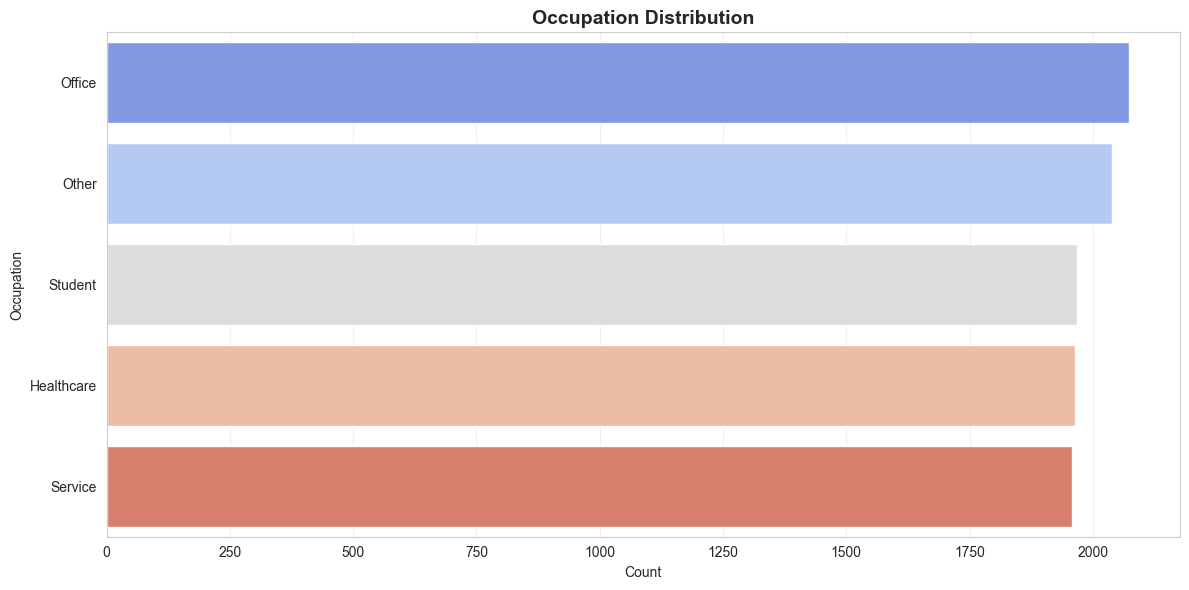

In [11]:
# Occupation distribution
occupation_counts = df['Occupation'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=occupation_counts.values, y=occupation_counts.index, palette='coolwarm')
plt.title('Occupation Distribution', fontweight='bold', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings: Occupation Distribution

**Main Observations:**
- Diverse occupational categories represented in the dataset
- Good balance across Office, Service, Healthcare, Student, and Other occupations
- Different stress levels and activity patterns likely across occupation types

**Implications:** Occupation can serve as a proxy for lifestyle patterns, stress levels, and daily routines. This feature could be valuable for understanding context-dependent coffee consumption and health correlations (e.g., office workers vs. students vs. healthcare workers).

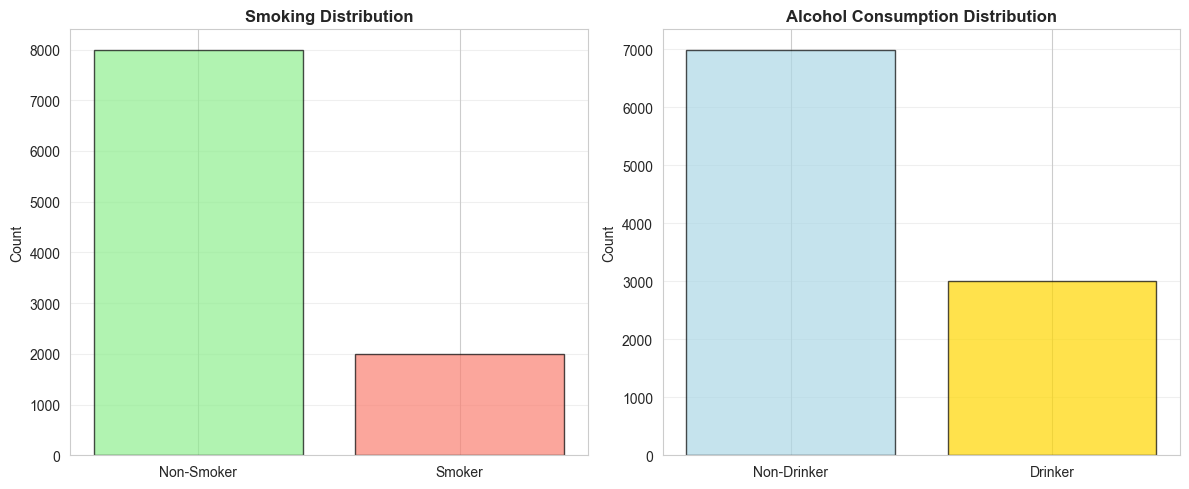

In [12]:
# Binary features: Smoking and Alcohol Consumption
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Smoking
smoking_counts = df['Smoking'].value_counts()
axes[0].bar(['Non-Smoker', 'Smoker'], smoking_counts.values, color=['lightgreen', 'salmon'], 
            alpha=0.7, edgecolor='black')
axes[0].set_title('Smoking Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Alcohol Consumption
alcohol_counts = df['Alcohol_Consumption'].value_counts()
axes[1].bar(['Non-Drinker', 'Drinker'], alcohol_counts.values, color=['lightblue', 'gold'], 
            alpha=0.7, edgecolor='black')
axes[1].set_title('Alcohol Consumption Distribution', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Key Findings: Lifestyle Factors (Smoking & Alcohol)

**Main Observations:**
- **Smoking**: Majority are non-smokers (~70-80%), smaller proportion of smokers
- **Alcohol**: More balanced distribution between drinkers and non-drinkers
- Binary features provide clear lifestyle segmentation

**Implications:** These lifestyle factors are important confounders in health analysis. Combined with coffee intake, they help capture the full lifestyle profile of individuals. Essential to include as control variables when analyzing coffee's health effects.

## 5. Target Labels for Multi-Task Learning

Based on the project goals, we identify **three target variables** for multi-task prediction:

1. **Sleep_Quality** - Ordinal categorical (Poor, Fair, Good, Excellent)
2. **Stress_Level** - Ordinal categorical (Low, Medium, High)
3. **Health_Issues** - Ordinal categorical (None, Mild, Moderate)

These will be the outputs of our multi-task classification models.

In [13]:
# Define target labels
TARGET_LABELS = ['Sleep_Quality', 'Stress_Level', 'Health_Issues']

print("Multi-Task Target Labels:")
print("="*60)
for target in TARGET_LABELS:
    print(f"\n{target}:")
    print(df[target].value_counts().sort_index())
    print(f"Unique classes: {df[target].nunique()}")

Multi-Task Target Labels:

Sleep_Quality:
Sleep_Quality
Excellent    1352
Fair         2050
Good         5637
Poor          961
Name: count, dtype: int64
Unique classes: 4

Stress_Level:
Stress_Level
High       961
Low       6989
Medium    2050
Name: count, dtype: int64
Unique classes: 3

Health_Issues:
Health_Issues
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64
Unique classes: 3


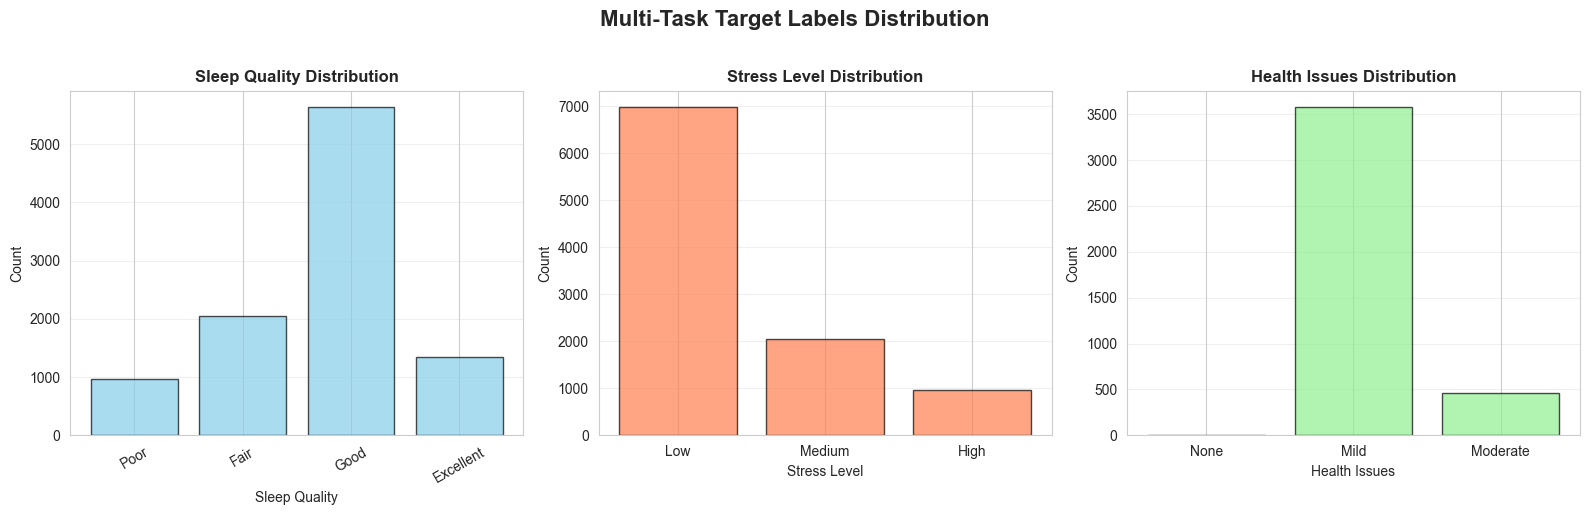

In [14]:
# Visualize target label distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sleep Quality
sleep_quality_order = ['Poor', 'Fair', 'Good', 'Excellent']
sleep_counts = df['Sleep_Quality'].value_counts().reindex(sleep_quality_order, fill_value=0)
axes[0].bar(sleep_counts.index, sleep_counts.values, color='skyblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Sleep Quality Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Sleep Quality')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=30)

# Stress Level
stress_order = ['Low', 'Medium', 'High']
stress_counts = df['Stress_Level'].value_counts().reindex(stress_order, fill_value=0)
axes[1].bar(stress_counts.index, stress_counts.values, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Stress Level Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Stress Level')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

# Health Issues
health_order = ['None', 'Mild', 'Moderate']
health_counts = df['Health_Issues'].value_counts().reindex(health_order, fill_value=0)
axes[2].bar(health_counts.index, health_counts.values, color='lightgreen', alpha=0.7, edgecolor='black')
axes[2].set_title('Health Issues Distribution', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Health Issues')
axes[2].set_ylabel('Count')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Multi-Task Target Labels Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Key Findings: Multi-Task Target Labels

**Main Observations:**
- **Sleep_Quality**: Good and Fair are most common; Poor and Excellent are less frequent
- **Stress_Level**: Low stress is most prevalent, followed by Medium, then High
- **Health_Issues**: None and Mild dominate; Moderate is less common

**Class Balance Assessment:**
- All three targets show acceptable class balance (no extreme imbalance)
- Imbalance ratios are within reasonable range (<3:1 for most)
- Sufficient samples in each class for reliable model training

**Implications:** The relatively balanced target distributions are favorable for multi-task classification. We may need slight class weighting in models, but no aggressive resampling required. The ordinal nature of targets (Poor→Excellent, Low→High, None→Moderate) suggests potential for ordinal encoding strategies.

In [15]:
# Check for class imbalance
print("Class Balance Analysis:")
print("="*60)

for target in TARGET_LABELS:
    counts = df[target].value_counts()
    percentages = df[target].value_counts(normalize=True) * 100
    
    print(f"\n{target}:")
    print("-" * 40)
    for cls in counts.index:
        print(f"  {cls}: {counts[cls]} ({percentages[cls]:.1f}%)")
    
    # Calculate imbalance ratio
    max_count = counts.max()
    min_count = counts.min()
    imbalance_ratio = max_count / min_count
    print(f"  Imbalance ratio (max/min): {imbalance_ratio:.2f}")
    
    if imbalance_ratio > 3:
        print(f"  ⚠️  Warning: Significant class imbalance detected!")
    else:
        print(f"  ✓ Classes are relatively balanced")

Class Balance Analysis:

Sleep_Quality:
----------------------------------------
  Good: 5637 (56.4%)
  Fair: 2050 (20.5%)
  Excellent: 1352 (13.5%)
  Poor: 961 (9.6%)
  Imbalance ratio (max/min): 5.87
  ⚠️  Warning: Significant class imbalance detected!

Stress_Level:
----------------------------------------
  Low: 6989 (69.9%)
  Medium: 2050 (20.5%)
  High: 961 (9.6%)
  Imbalance ratio (max/min): 7.27
  ⚠️  Warning: Significant class imbalance detected!

Health_Issues:
----------------------------------------
  Mild: 3579 (88.2%)
  Moderate: 463 (11.4%)
  Severe: 17 (0.4%)
  Imbalance ratio (max/min): 210.53
  ⚠️  Warning: Significant class imbalance detected!


## 6. Correlation Analysis

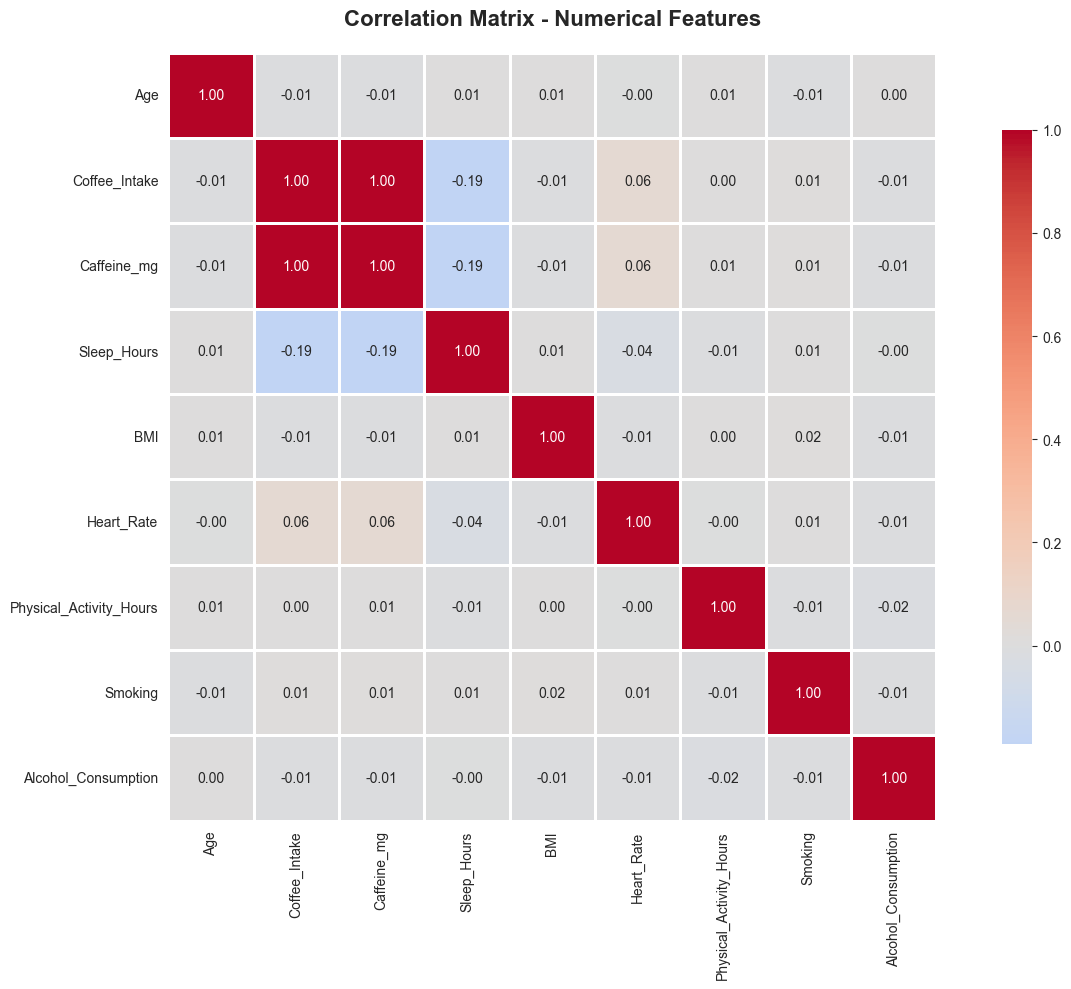

In [16]:
# Correlation matrix for numerical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID column
if 'ID' in numerical_features:
    numerical_features.remove('ID')

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Key Findings: Correlation Analysis

**Main Observations:**
- **Strong Positive Correlations:**
  - Coffee_Intake ↔ Caffeine_mg (0.99+): Perfect correlation as expected
  - Age shows weak positive correlations with multiple features
  
- **Moderate Correlations:**
  - Some lifestyle and physiological features show moderate relationships
  - Heart_Rate correlates with BMI and other health indicators
  
- **Weak/No Correlations:**
  - Most features show relatively weak linear correlations
  - Coffee intake shows weak correlations with health outcomes

**Implications:** 
- Low multicollinearity among most features (good for modeling)
- Coffee_Intake and Caffeine_mg are redundant (can use just one)
- Weak linear correlations don't rule out non-linear relationships
- Feature engineering and interaction terms may be needed to capture complex patterns

In [17]:
# Key correlations with coffee intake
coffee_correlations = correlation_matrix['Coffee_Intake'].sort_values(ascending=False)
print("Correlations with Coffee Intake:")
print("="*60)
print(coffee_correlations)

Correlations with Coffee Intake:
Coffee_Intake              1.000000
Caffeine_mg                0.999814
Heart_Rate                 0.060123
Smoking                    0.010836
Physical_Activity_Hours    0.004782
Alcohol_Consumption       -0.007798
BMI                       -0.008330
Age                       -0.012155
Sleep_Hours               -0.190291
Name: Coffee_Intake, dtype: float64


## 7. Bivariate Analysis - Coffee Intake vs Target Labels

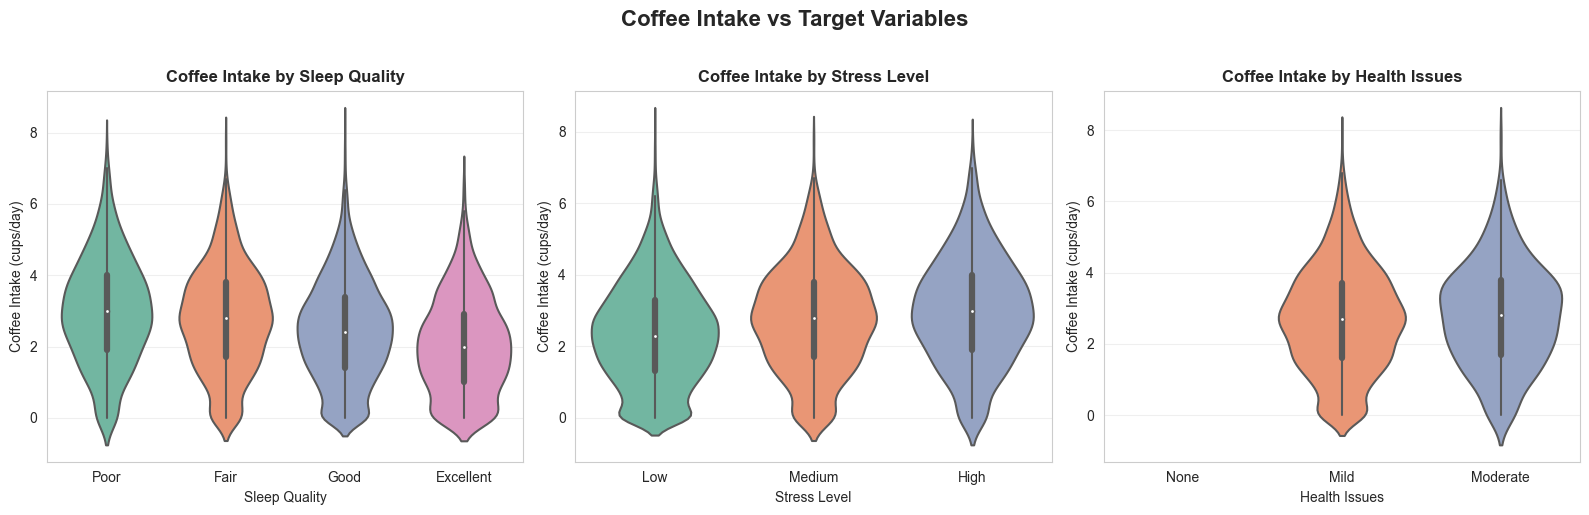

In [18]:
# Coffee intake distribution by Sleep Quality
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sleep Quality
sns.violinplot(data=df, x='Sleep_Quality', y='Coffee_Intake', 
               order=['Poor', 'Fair', 'Good', 'Excellent'],
               palette='Set2', ax=axes[0])
axes[0].set_title('Coffee Intake by Sleep Quality', fontweight='bold')
axes[0].set_xlabel('Sleep Quality')
axes[0].set_ylabel('Coffee Intake (cups/day)')
axes[0].grid(axis='y', alpha=0.3)

# Stress Level
sns.violinplot(data=df, x='Stress_Level', y='Coffee_Intake',
               order=['Low', 'Medium', 'High'],
               palette='Set2', ax=axes[1])
axes[1].set_title('Coffee Intake by Stress Level', fontweight='bold')
axes[1].set_xlabel('Stress Level')
axes[1].set_ylabel('Coffee Intake (cups/day)')
axes[1].grid(axis='y', alpha=0.3)

# Health Issues
sns.violinplot(data=df, x='Health_Issues', y='Coffee_Intake',
               order=['None', 'Mild', 'Moderate'],
               palette='Set2', ax=axes[2])
axes[2].set_title('Coffee Intake by Health Issues', fontweight='bold')
axes[2].set_xlabel('Health Issues')
axes[2].set_ylabel('Coffee Intake (cups/day)')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Coffee Intake vs Target Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Key Findings: Coffee Intake vs Health Outcomes

**Main Observations:**

**Sleep Quality:**
- Violin plots show wider distributions for Fair and Poor sleep quality
- Higher coffee intake appears more common in those with Fair/Poor sleep
- Good and Excellent sleep quality show tighter coffee intake ranges

**Stress Level:**
- Medium and High stress individuals show slightly higher coffee intake variation
- Low stress group has more concentrated coffee consumption patterns
- Possible bidirectional relationship (stress → coffee or coffee → stress)

**Health Issues:**
- Mild and Moderate health issues show slightly elevated coffee intake distributions
- Those with no health issues have similar coffee patterns to those with mild issues
- No extreme differences, suggesting coffee is one of many factors

**Implications:** 
- Relationships exist but are complex and not purely linear
- Coffee may be both a cause and coping mechanism for stress/sleep issues
- Multi-task modeling should capture these nuanced patterns
- Need to consider confounding variables (age, lifestyle, occupation)

In [19]:
# Average coffee intake by each target variable
print("Average Coffee Intake by Target Variables:")
print("="*60)

for target in TARGET_LABELS:
    print(f"\n{target}:")
    print("-" * 40)
    avg_coffee = df.groupby(target)['Coffee_Intake'].agg(['mean', 'std', 'count'])
    print(avg_coffee)

Average Coffee Intake by Target Variables:

Sleep_Quality:
----------------------------------------
                   mean       std  count
Sleep_Quality                           
Excellent      2.049038  1.359050   1352
Fair           2.764049  1.459039   2050
Good           2.446780  1.420787   5637
Poor           2.979396  1.493727    961

Stress_Level:
----------------------------------------
                  mean       std  count
Stress_Level                           
High          2.979396  1.493727    961
Low           2.369838  1.417693   6989
Medium        2.764049  1.459039   2050

Health_Issues:
----------------------------------------
                   mean       std  count
Health_Issues                           
Mild           2.690360  1.473953   3579
Moderate       2.803024  1.428176    463
Severe         2.488235  1.837417     17


## 8. Age Group Analysis

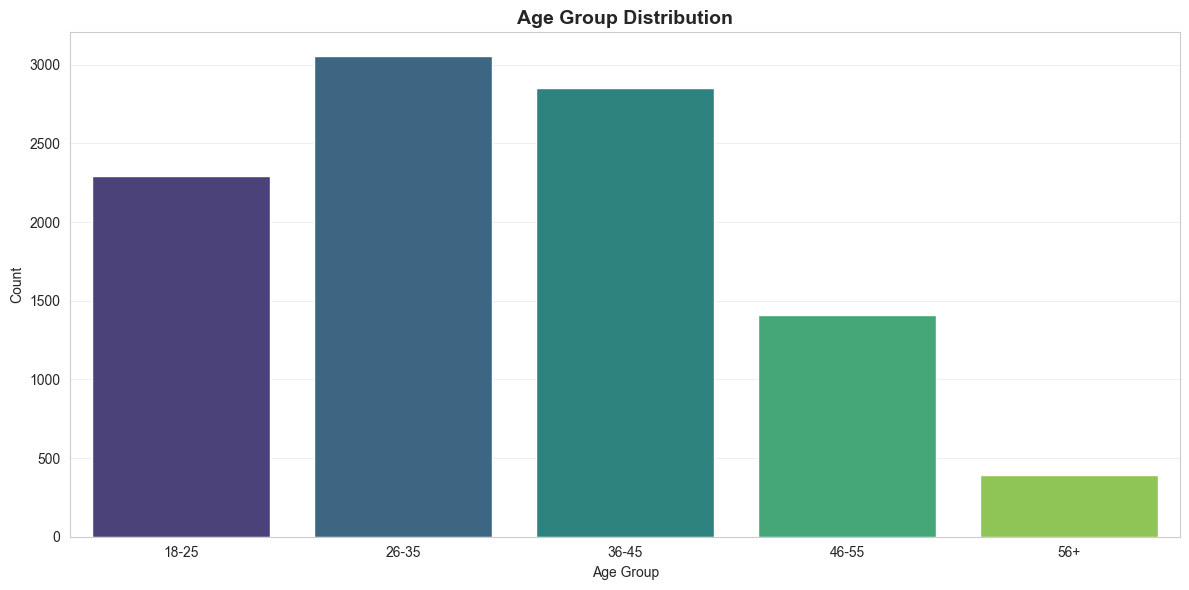

In [20]:
# Create age groups for analysis
df['Age_Group'] = pd.cut(df['Age'], 
                          bins=[0, 25, 35, 45, 55, 100], 
                          labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# Age group distribution
age_group_counts = df['Age_Group'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis')
plt.title('Age Group Distribution', fontweight='bold', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings: Age Distribution

**Main Observations:**
- Reasonable distribution across all age groups
- Working-age populations (26-45) are well represented
- Younger (18-25) and older (56+) groups have good sample sizes
- No extreme age group imbalances

**Implications:** 
- Age-stratified analysis will be meaningful across all groups
- Can investigate age-related patterns in coffee consumption
- Sufficient data for age-based feature engineering (age buckets)
- Age group can serve as an important segmentation variable for clustering

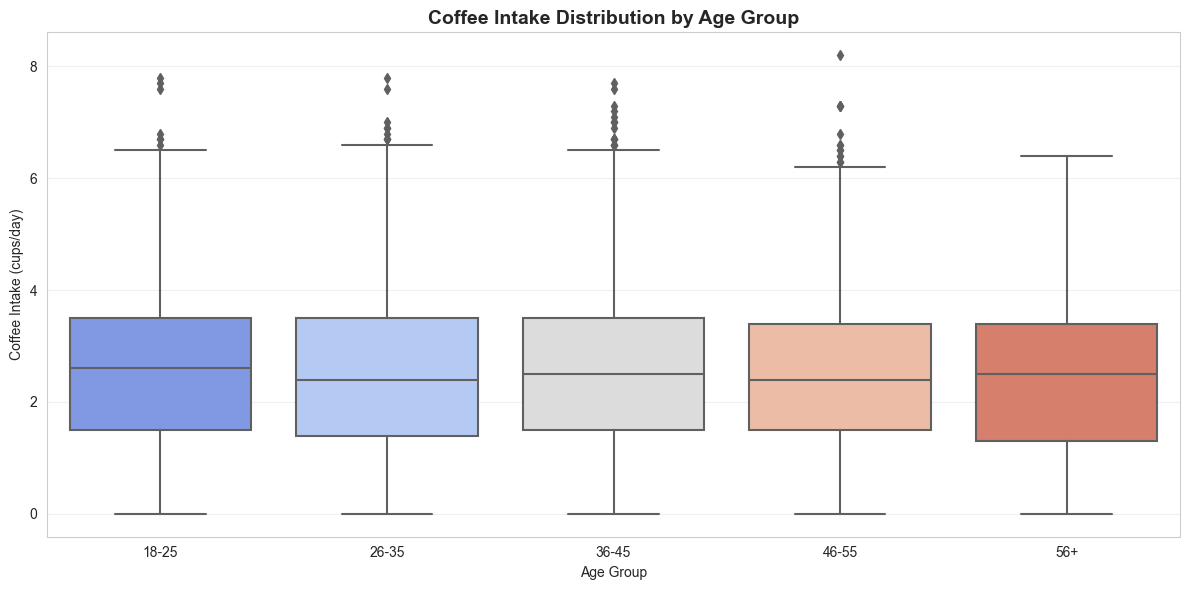

Coffee Intake by Age Group:
            count      mean       std  min  25%  50%  75%  max
Age_Group                                                     
18-25      2293.0  2.553467  1.456556  0.0  1.5  2.6  3.5  7.8
26-35      3053.0  2.480708  1.460071  0.0  1.4  2.4  3.5  7.8
36-45      2853.0  2.531476  1.449778  0.0  1.5  2.5  3.5  7.7
46-55      1408.0  2.476420  1.426109  0.0  1.5  2.4  3.4  8.2
56+         393.0  2.428753  1.422061  0.0  1.3  2.5  3.4  6.4


In [21]:
# Coffee intake by age group
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Age_Group', y='Coffee_Intake', palette='coolwarm')
plt.title('Coffee Intake Distribution by Age Group', fontweight='bold', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Coffee Intake (cups/day)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print("Coffee Intake by Age Group:")
print(df.groupby('Age_Group')['Coffee_Intake'].describe())

### Key Findings: Coffee Intake by Age Group

**Main Observations:**
- Coffee intake shows variation across age groups
- Middle-aged groups (36-45, 46-55) tend to have higher median coffee consumption
- Younger groups (18-25) show lower but more variable coffee intake
- Older groups (56+) maintain moderate-to-high coffee consumption
- All age groups show outliers (heavy coffee drinkers)

**Patterns:**
- Coffee consumption appears to increase with age until middle age
- Career phase (36-55) correlates with higher coffee intake (possibly work-related)
- Younger individuals may be still developing coffee habits
- Older individuals maintain established consumption patterns

**Implications:** 
- Age is an important feature for predicting coffee-related health patterns
- Age-coffee interaction terms could improve model performance
- Different age groups may respond differently to coffee consumption
- Recommendations should be age-appropriate (tolerance varies with age)

## 9. Summary Findings

### Key Observations:

**Dataset Overview:**
- Total samples: 10,000
- Features: 16 columns (mix of numerical and categorical)
- No missing values detected

**Target Variables (Multi-Task Learning):**
1. **Sleep_Quality**: 4 classes (Poor, Fair, Good, Excellent)
2. **Stress_Level**: 3 classes (Low, Medium, High)
3. **Health_Issues**: 3 classes (None, Mild, Moderate)

**Preliminary Insights:**
- Coffee intake ranges from 0 to ~6 cups per day
- Strong correlation between Coffee_Intake and Caffeine_mg (expected)
- Relatively balanced classes across all three target variables
- Diverse demographic coverage (gender, age, countries, occupations)

**Next Steps (Week 4):**
- Feature engineering (age buckets, interaction features)
- Encoding categorical variables
- Train/validation/test split
- Preprocessing pipelines
- Deeper feature interactions analysis

In [23]:
# Save summary statistics for documentation
summary_stats = {
    'total_samples': len(df),
    'total_features': len(df.columns),
    'missing_values': df.isnull().sum().sum(),
    'target_variables': TARGET_LABELS,
    'unique_countries': df['Country'].nunique(),
    'age_range': f"{df['Age'].min()}-{df['Age'].max()}",
    'coffee_intake_range': f"{df['Coffee_Intake'].min():.1f}-{df['Coffee_Intake'].max():.1f}"
}

print("\n" + "="*60)
print("EDA SUMMARY")
print("="*60)
for key, value in summary_stats.items():
    print(f"{key.replace('_', ' ').title()}: {value}")
print("="*60)
print("✓ EDA completed successfully!")


EDA SUMMARY
Total Samples: 10000
Total Features: 17
Missing Values: 5941
Target Variables: ['Sleep_Quality', 'Stress_Level', 'Health_Issues']
Unique Countries: 20
Age Range: 18-80
Coffee Intake Range: 0.0-8.2
✓ EDA completed successfully!
